In [ ]:
# https://pytorch.org/vision/stable/models.html#general-information-on-pre-trained-weights

In [1]:
import torch
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
import json
import os

# 设置 PyTorch 的模型下载镜像地址（清华镜像源）
# os.environ['TORCH_HOME'] = 'https://pytorch.tuna.tsinghua.edu.cn/models'
# os.environ['TORCH_HOME'] = 'https://mirror.aliyun.com/pytorch/models'

# 替换默认的下载地址为清华镜像
torch.hub._download_url_to_file = lambda url, dst, hash_prefix, progress: torch.hub.download_url_to_file(
    url.replace('https://download.pytorch.org', 'https://pytorch.tuna.tsinghua.edu.cn'), dst, hash_prefix, progress
)



In [2]:
# 定义预处理变换
# transform = transforms.Compose([
#     transforms.Resize(256),  # 缩放图片，最短边为 256 像素
#     transforms.CenterCrop(224),  # 中心裁剪 224x224 像素
#     transforms.ToTensor(),  # 转换为 Tensor
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # 归一化
# ])

# 加载预训练的 VGG-16 模型
weights = models.VGG16_Weights.DEFAULT
# Step 2: Initialize the inference transforms
transform = weights.transforms()
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
model.eval()  # 设置模型为评估模式
print("done")

done


In [3]:
from torchsummary import summary

# 打印模型概要信息
summary(model, (3, 224, 224),device="cpu")


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [4]:
X = torch.randn(1, 1, 224, 224)
for idx,layer in enumerate(model.features):
    print(idx,layer.__class__.__name__)

0 Conv2d
1 ReLU
2 Conv2d
3 ReLU
4 MaxPool2d
5 Conv2d
6 ReLU
7 Conv2d
8 ReLU
9 MaxPool2d
10 Conv2d
11 ReLU
12 Conv2d
13 ReLU
14 Conv2d
15 ReLU
16 MaxPool2d
17 Conv2d
18 ReLU
19 Conv2d
20 ReLU
21 Conv2d
22 ReLU
23 MaxPool2d
24 Conv2d
25 ReLU
26 Conv2d
27 ReLU
28 Conv2d
29 ReLU
30 MaxPool2d


In [5]:
# 加载图片
image_path = '../datasets/imagenet-sample-images-master/n01443537_goldfish.JPEG'  # 替换为你的图片路径
image = Image.open(image_path).convert('RGB')

# 应用预处理
image_tensor = transform(image)
image_tensor = image_tensor.unsqueeze(0)  # 增加 batch 维度

# 进行推理
with torch.no_grad():
    output = model(image_tensor)

# 获取预测结果
prediction = model(image_tensor).squeeze(0).softmax(0)
class_id = prediction.argmax().item()
score = prediction[class_id].item()
category_name = weights.meta["categories"][class_id]
print(f"{category_name}: {100 * score:.1f}%")

goldfish: 99.8%


### 1. 卷积核可视化（Filter Visualization）

描述：
 可视化卷积层的权重（filters/kernel），了解每个卷积核学到了什么特征。
 通过直观展示每个卷积核的权重，研究哪些类型的边缘、纹理或模式是网络感兴趣的。

方法：
 提取 CNN 中每一层的卷积核权重，直接将其可视化为图像。

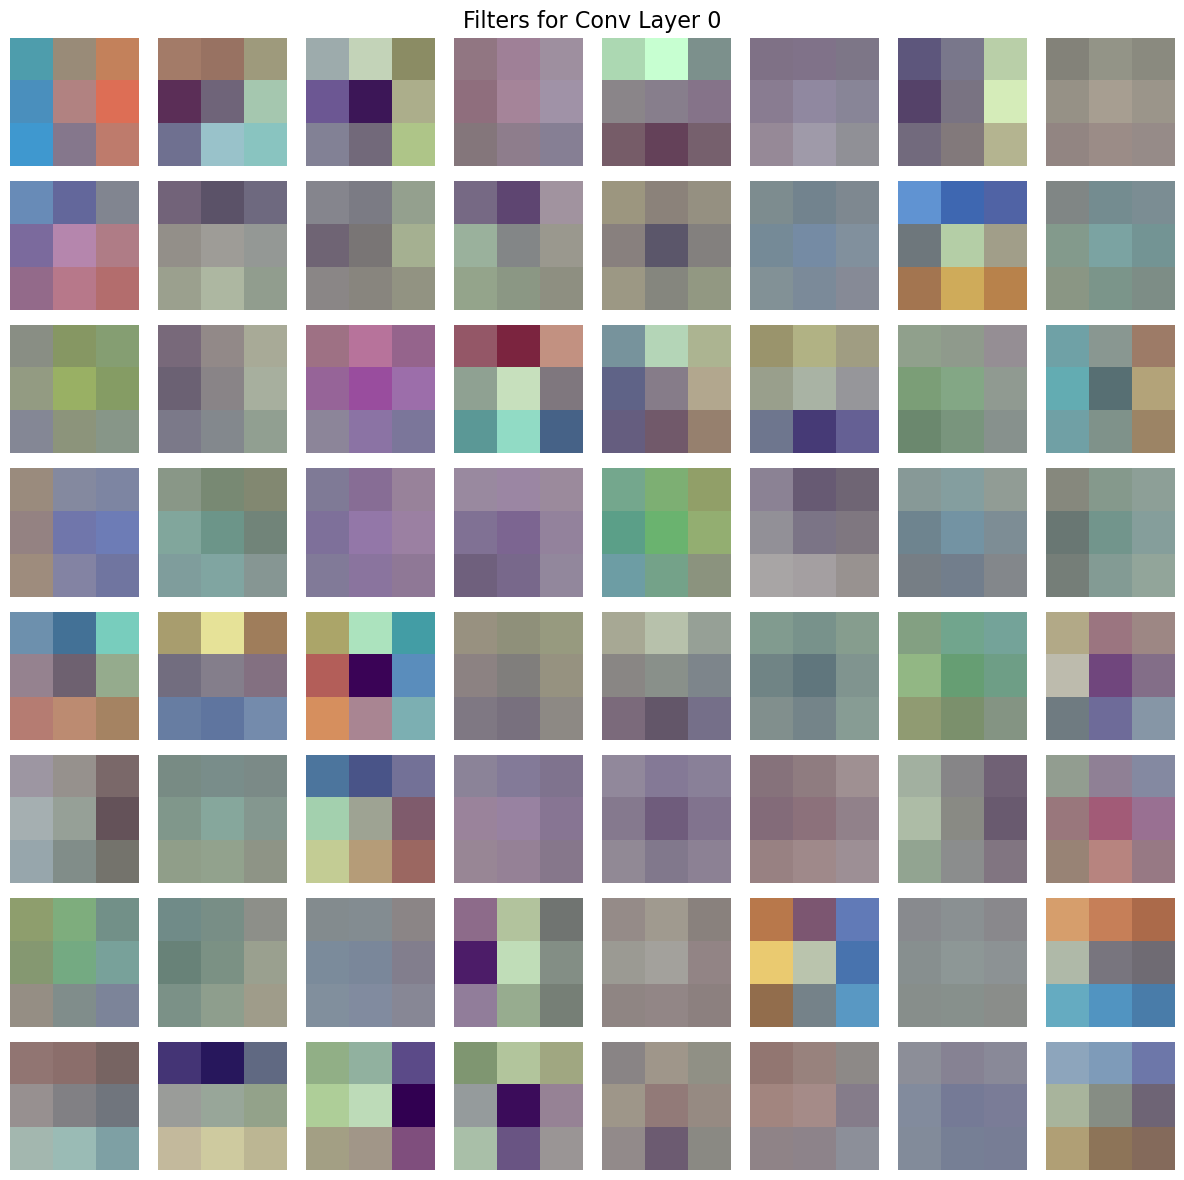

In [6]:
import matplotlib.pyplot as plt
# 选择要可视化的卷积层
layer_name = 0  # 例如，选择第一个卷积层

# 提取卷积层的权重
conv_layer = model.features[layer_name]
weights = conv_layer.weight.data.cpu().numpy()

# 归一化权重
def normalize_weights(weights):
    min_val = weights.min()
    max_val = weights.max()
    normalized_weights = (weights - min_val) / (max_val - min_val)
    return normalized_weights

normalized_weights = normalize_weights(weights)

# 显示卷积核
num_filters = normalized_weights.shape[0]
fig, axes = plt.subplots(nrows=num_filters // 8, ncols=8, figsize=(12, 12))
fig.suptitle(f'Filters for Conv Layer {layer_name}', fontsize=16)

for i, ax in enumerate(axes.flatten()):
    if i < num_filters:
        ax.imshow(normalized_weights[i].transpose(1, 2, 0), cmap='gray')
        ax.axis('off')
    else:
        fig.delaxes(ax)

plt.tight_layout()
plt.show()

### 2 特征图可视化（Feature Map Visualization）

描述：
提取卷积层的中间特征图（feature maps），观察输入通过网络后，在不同卷积层激活的特征。
直观分析网络如何逐层提取特征，例如低层提取边缘、高层提取语义模式。
  
方法：
将输入图像喂入网络，获取不同层的输出特征图。
对每个特征图进行归一化处理，并可视化为灰度图或热图。

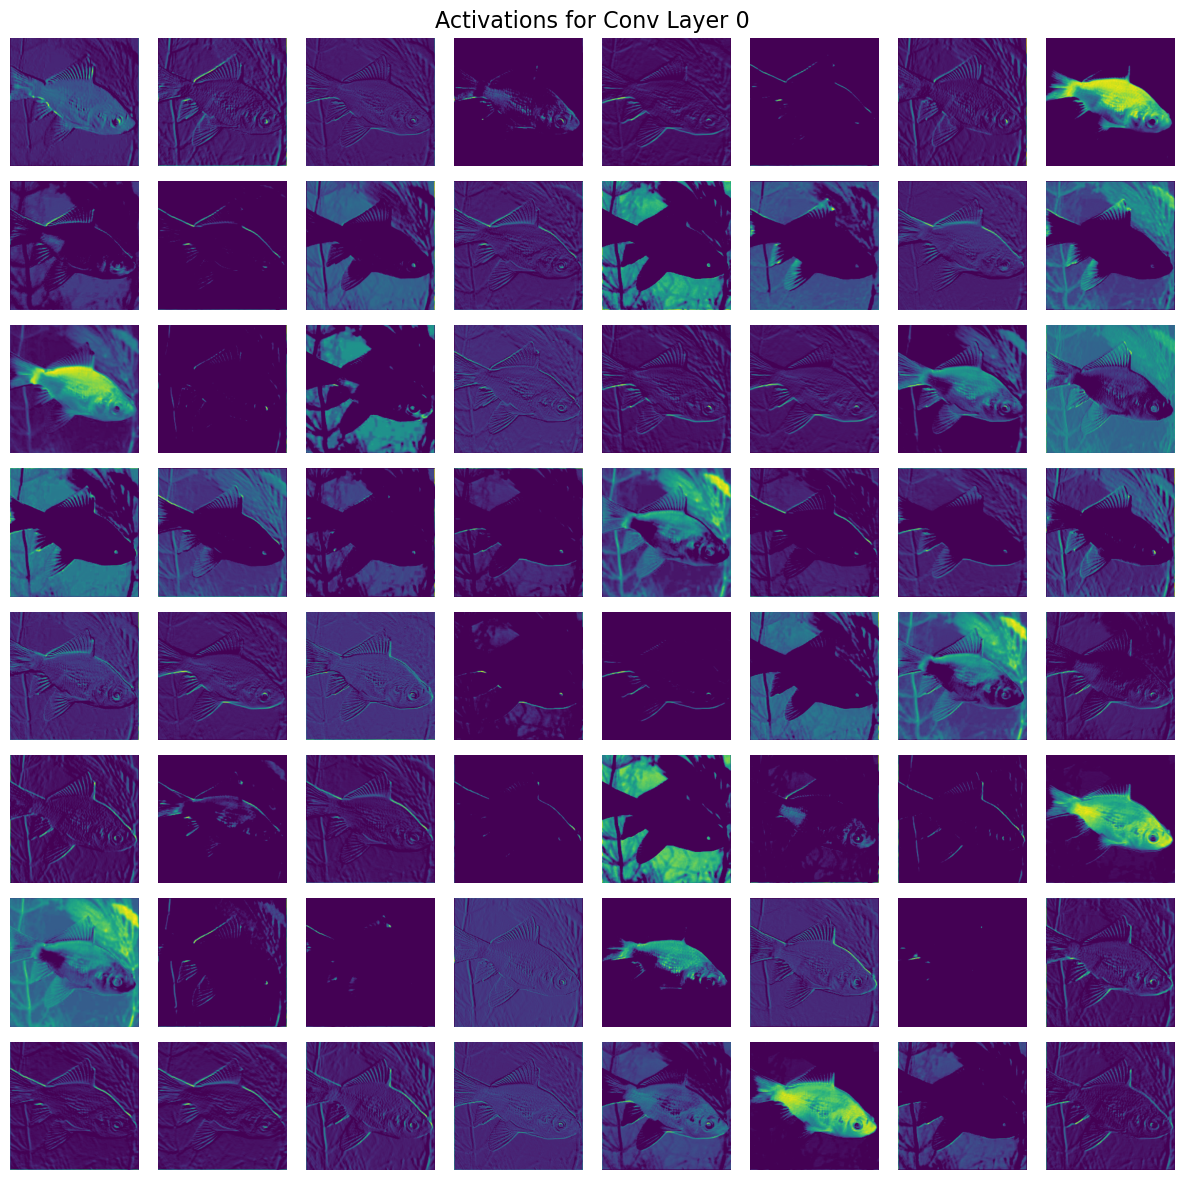

In [7]:
import matplotlib.pyplot as plt
# # 定义一个函数来提取和可视化卷积层的激活图
# def visualize_conv_layers(model, image_tensor, layer_name):
#     activation = {}

#     def get_activation(name):
#         def hook(model, input, output):
#             activation[name] = output.detach()
#         return hook

#     handle = model.features[layer_name].register_forward_hook(get_activation(layer_name))
    
#     with torch.no_grad():
#         output = model(image_tensor)
    
#     handle.remove()
    
#     return activation[layer_name]

def visualize_conv_layers(model, image_tensor, layer_name):
    activation = {}
    handle = model.features[layer_name].register_forward_hook(
        lambda model, input, output: activation.setdefault(layer_name, output.detach())
    )
    
    with torch.no_grad():
        output = model(image_tensor)
    handle.remove()
    return activation[layer_name]


# 选择要可视化的卷积层
layer_name = 0  # 例如，选择第一个卷积层

# 提取卷积层的激活图
activations = visualize_conv_layers(model, image_tensor, layer_name)


# 归一化激活图数据
def normalize_activation(activation):
    min_val = activation.min()
    max_val = activation.max()
    normalized_activation = (activation - min_val) / (max_val - min_val)
    return normalized_activation

# 显示卷积层的纹理
num_filters = activations.shape[1]
fig, axes = plt.subplots(nrows=num_filters // 8, ncols=8, figsize=(12, 12))
fig.suptitle(f'Activations for Conv Layer {layer_name}', fontsize=16)

for i, ax in enumerate(axes.flatten()):
    if i < num_filters:
        normalized_activation = normalize_activation(activations[0, i].cpu().numpy())
        ax.imshow(normalized_activation, cmap='viridis')
        ax.axis('off')
    else:
        fig.delaxes(ax)

plt.tight_layout()
plt.show()

### 3. 类激活图（Class Activation Mapping, CAM）
 描述：

 通过生成类激活图，展示网络在预测某个类别时的关注区域。
 CAM 使用的是全局平均池化（GAP）层后的特征乘以分类器权重，以定位网络的关注区域。

 https://github.com/jacobgil/pytorch-grad-cam

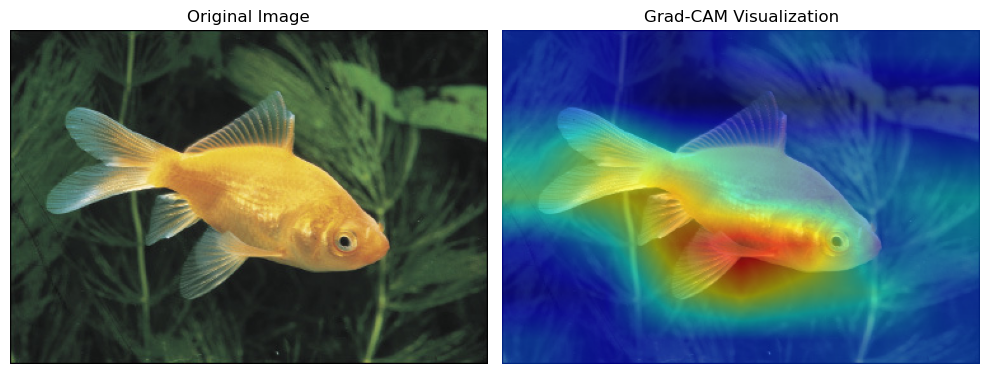

In [9]:
from pytorch_grad_cam import GradCAM,GradCAMPlusPlus
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# 3. 创建 Grad-CAM 对象并指定目标层
target_layer = model.features[-1]  # VGG16 最后一层特征图 
cam = GradCAM(model=model, target_layers=[target_layer])

# 4. 生成热力图
# targets = [ClassifierOutputTarget(1)]  # 可选：指定类别（1 是 ImageNet 的 'goldfish' 类别）
# grayscale_cam = cam(input_tensor=image_tensor, targets=targets)
grayscale_cam = cam(input_tensor=image_tensor)  # 不指定 targets,GradCAM 将使用模型的最大激活值来生成热力图，而不需要指定具体的分类输出目标
grayscale_cam = grayscale_cam[0, :]  # 获取第一个样本的热力图

# 5. 调整热力图大小以匹配原始图像
original_image = transforms.ToTensor()(image).permute(1, 2, 0).numpy()
original_image = original_image - original_image.min()
original_image = original_image / original_image.max()

# 使用 OpenCV 将热力图调整到原始图像大小
grayscale_cam_resized = cv2.resize(grayscale_cam, (original_image.shape[1], original_image.shape[0]))

# 将热力图叠加到原始图像上
visualization = show_cam_on_image(original_image, grayscale_cam_resized, use_rgb=True)

# 6. 显示结果
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(original_image)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Grad-CAM Visualization')
plt.imshow(visualization)
plt.axis('off')

plt.tight_layout()
plt.show()